# Identify lung-specific gene expression in each cell type
1. [Visualize QC statistics in lung and spleen samples](#section1)
2. [Rename cell types for simplicity](#section2)
3. [Identify marker genes for each cell type](#section3)
4. [cross-tissue DE analysis in each cell type](#section4)
5. [Examine the functions of lung or spleen DE genes](#section5)

In [ ]:
## Load package and the seurat object
library(Seurat)
library(data.table)
library(dplyr)
library(ggplot2)
library(plotly)
library(patchwork)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(GOSemSim)
library(gridExtra)
library(slingshot)
source("code/make_plots.R")

In [8]:
immune.combined<-readRDS("lungs_spleens_processed.rds"))
immune.combined@active.assay<-"RNA"
immune.combined
platte = c("#D51F26","#272E6A", "#208A42", "#89288F", "#F47D2B", "#FEE500", "#8A9FD1", "#C06CAB")
ct_order <-
  c(
  "Naive_B",
  "Memory_B",
  "NK",
  "CD8_T",
  "CD4_T",
  "Th17",
  "Treg",
  "Other"
)

An object of class Seurat 
321136 features across 53647 samples within 4 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 3 other assays present: ATAC, integrated, peaks
 3 dimensional reductions calculated: pca, umap, lsi

<a id='section1'></a>
## 1 Visualize QC statistics in lung and spleen samples

In [ ]:
lung<-readRDS("AGG_lungs/all_lungs_integrated_multi.rds")

p1 <- VlnPlot(lung, features = c("nCount_ATAC"),#, "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend() + 
    theme(axis.text.y = element_text(size = 15),
          axis.title.x = element_blank(),
          axis.text.x = element_blank()) 
p2 <- VlnPlot(lung, features = c("nCount_RNA"), 
  log = TRUE, pt.size = 0) + NoLegend() + 
    theme(axis.text.y = element_text(size = 15),
          axis.title.x = element_blank(),
          axis.text.x = element_blank()) 
p3 <- VlnPlot(lung, features = c("percent.mt"), 
  log = TRUE, pt.size = 0) + NoLegend() + 
    theme(axis.text.y = element_text(size = 15),
          axis.title.x = element_blank(),
          axis.text.x = element_blank()) 

#ggsave(p1|p2|p3, filename = "aggr_lung_statistics.pdf", width = 10, height = 4)

In [4]:
spleen<-readRDS("AGG_spleens/all_spleens_integrated_multi.rds")

p1 <- VlnPlot(lung, features = c("nCount_ATAC"),#, "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend() + 
    theme(axis.text.y = element_text(size = 15),
          axis.title.x = element_blank(),
          axis.text.x = element_blank()) 
p2 <- VlnPlot(lung, features = c("nCount_RNA"), 
  log = TRUE, pt.size = 0) + NoLegend() + 
    theme(axis.text.y = element_text(size = 15),
          axis.title.x = element_blank(),
          axis.text.x = element_blank()) 
p3 <- VlnPlot(lung, features = c("percent.mt"), 
  log = TRUE, pt.size = 0) + NoLegend() + 
    theme(axis.text.y = element_text(size = 15),
          axis.title.x = element_blank(),
          axis.text.x = element_blank()) 

#ggsave(p1|p2|p3, filename = "aggr_spleen_statistics.pdf", width = 10, height = 4)

In [18]:
Idents(immune.combined)<-"full.ident"
batch.ids<-c("batch1", "batch1", "batch2", "batch3", "batch3", "batch2", "batch2", "batch3", "batch1")
names(batch.ids) <- levels(immune.combined)
immune.combined<-RenameIdents(immune.combined, batch.ids)

immune.combined@meta.data[,"batch"] <- Idents(immune.combined)
# immune.combined@meta.data[, "tissue_and_batch"] <- paste(immune.combined$tissue.ident,
#                                                          immune.combined$batch,
#                                                           sep="_")

In [ ]:
# prepare covariate input for dictys
clusters<-read.csv("clusters_merged.csv", header = T)

colnames(clusters)[1]<-"new_ids"

clusters<-left_join(clusters, 
                    immune.combined@meta.data %>% dplyr::select(batch, new_ids), 
                    by = "new_ids")

write.csv(clusters %>% dplyr::select(new_ids, batch), "covariates_merged.csv", row.names=F, quote = F)

<a id='section2'></a>

## 2 Rename cell types for simplicity

In [ ]:
immune.combined$CellType <- 
factor(immune.combined$majority_voting,
       labels = c("NK",
                  "NK", "Other", 
                  "Other", "Other",
                  "Memory_B","Naive_B", "Other",
                  "Treg", "CD4_T", 
                  "CD8_T", "Th17")
       )
immune.combined$CellType <- factor(
    immune.combined$CellType,
    levels = 
            c("Other", "Treg", "Th17", "CD4_T",
              "CD8_T", "NK", "Memory_B", "Naive_B"))

In [ ]:
## UMAP visualization for integrated dataset colored by tissue, batch, cell type
p1 <- 
DimPlot(immune.combined, reduction = "pca", 
              group.by = "tissue.ident", 
              cols = platte, 
              #split.by = "tissue.ident", 
              label = FALSE, 
              repel = TRUE) +
    theme(legend.text = element_text(size = 18))
p2 <- 
DimPlot(immune.combined, reduction = "pca", 
              group.by = "batch", 
              cols = platte, 
              #split.by = "tissue.ident", 
              label = FALSE, 
              repel = TRUE) +
    theme(legend.text = element_text(size = 18))
p3 <- 
DimPlot(immune.combined, reduction = "pca", 
              group.by = "CellType", 
              cols = platte, 
              #split.by = "tissue.ident", 
              label = FALSE, 
              repel = TRUE) +
    theme(legend.text = element_text(size = 18))
p1 + p2 + p3

<a id='section3'></a>

## 3 Identify marker genes for each cell type

In [ ]:
## differential expression analysis across cell types with the Wilcoxon rank sum test

immune.markers <- FindAllMarkers(immune.combined,
                                 group.by = immune.combined$CellType,
                                 only.pos = TRUE)
immune.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1)

immune.markers %>%
    group_by(cluster) %>%
    dplyr::filter(p_val_adj < 0.001) %>%
    arrange(desc(avg_log2FC)) %>%
    slice_head(n = 5) %>%
    ungroup() -> top5

### Dotplots for the expression of known marker genes across immune cells

In [5]:
markerGenes <- c("CD69","IGHD", "IL4R", "MS4A1",
      "BANK1", "MEF2C", "EBF1",
      "GNLY", "NKG7",
      "CD8B", "ITGA1", "GZMK",
      "LEF1", "TCF7", "IL7R",
      "CCL20", "CCR6",
      "CTLA4", "IL2RA", "FOXP3")

In [6]:
Idents(immune.combined) <- immune.combined$CellType
p2 <-
    DotPlot(subset(immune.combined, subset= CellType != "Other"),
        features = markerGenes) + 
    RotatedAxis() + xlab("") + ylab("") + 
    #scale_y_discrete(limits = rev) + 
    theme_classic(base_size = 12) + 
    theme(axis.text.x = element_text(size = 11, angle = 45, vjust=0.6),
          axis.title = element_text(size = 13),
          legend.title = element_text(size = 11),
          legend.text = element_text(size = 10))

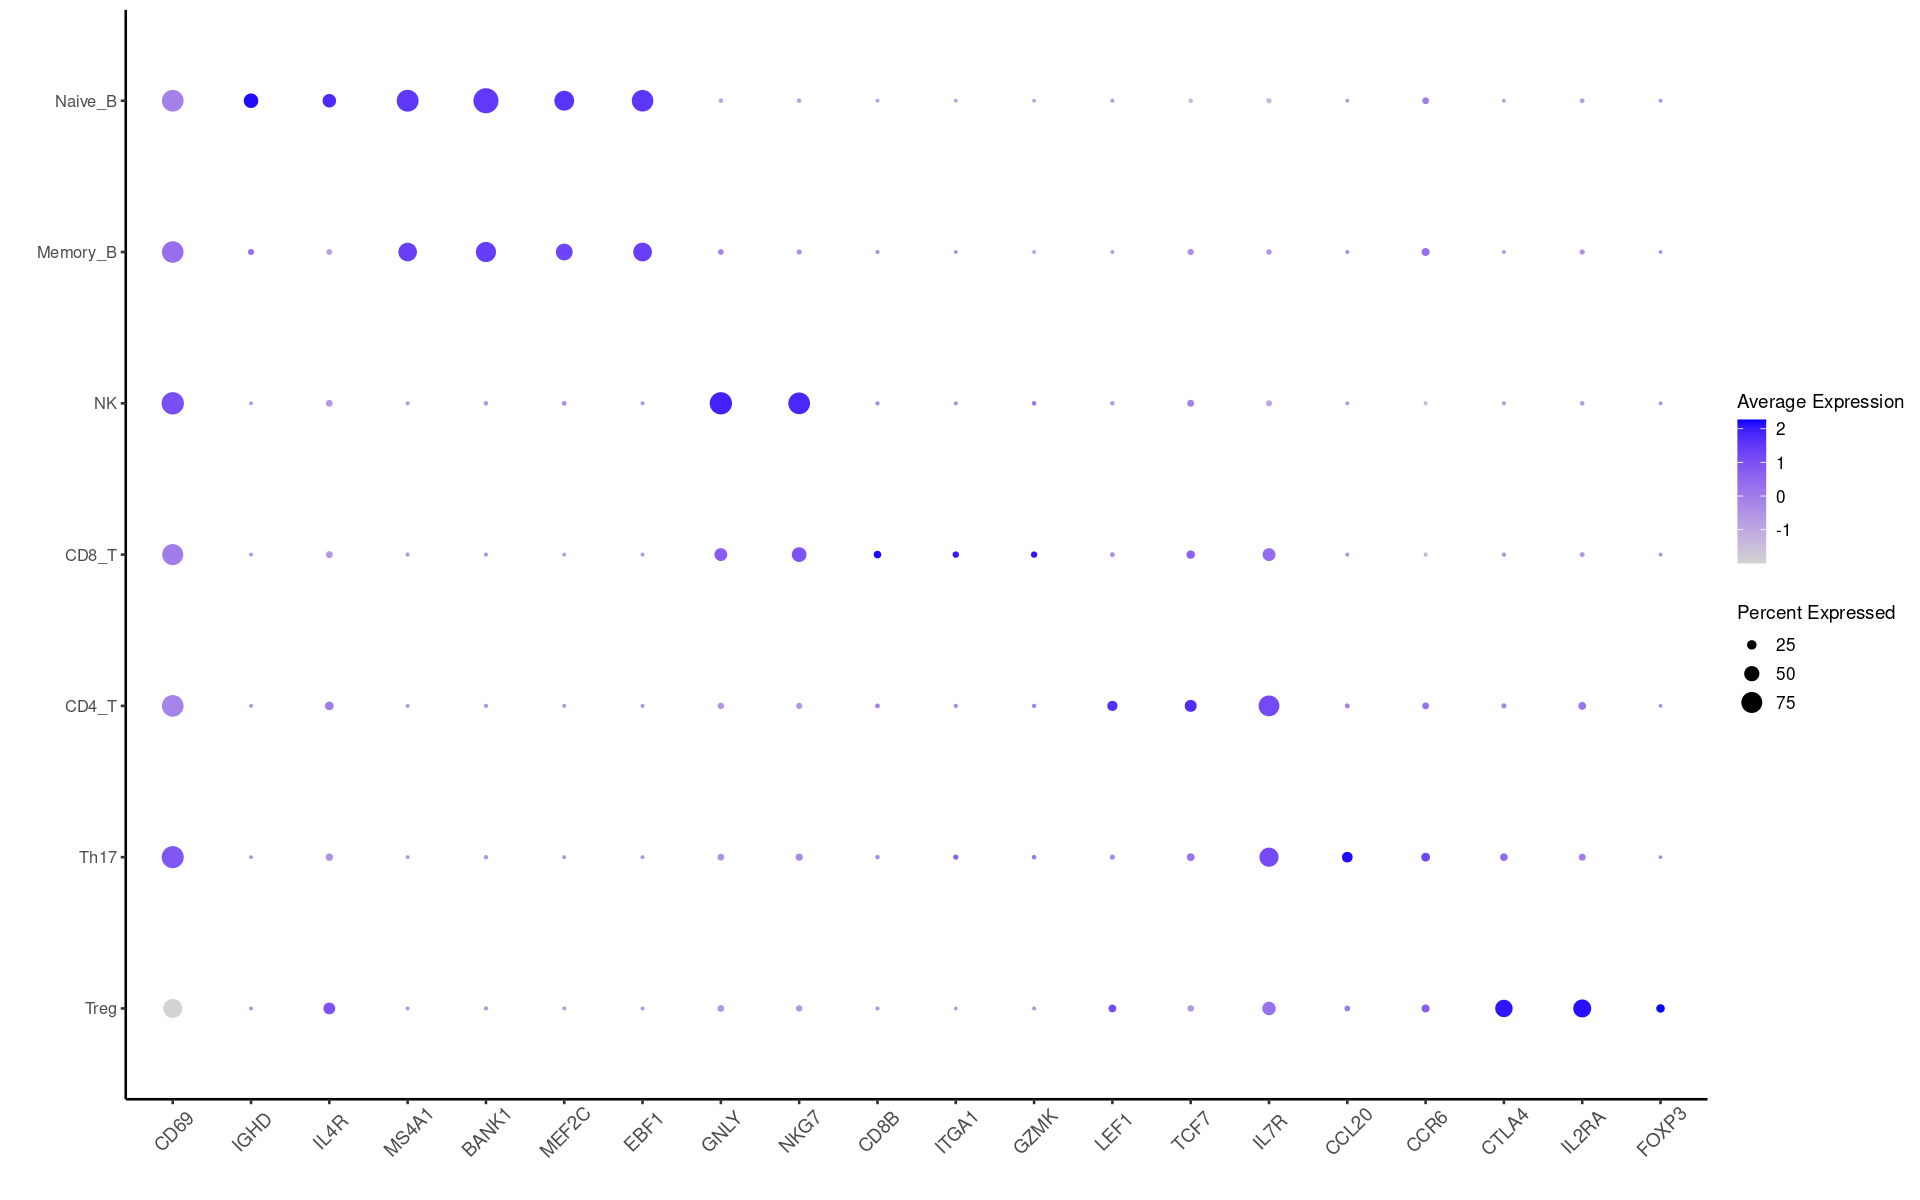

In [7]:
p2

### Dotplot split by tissue

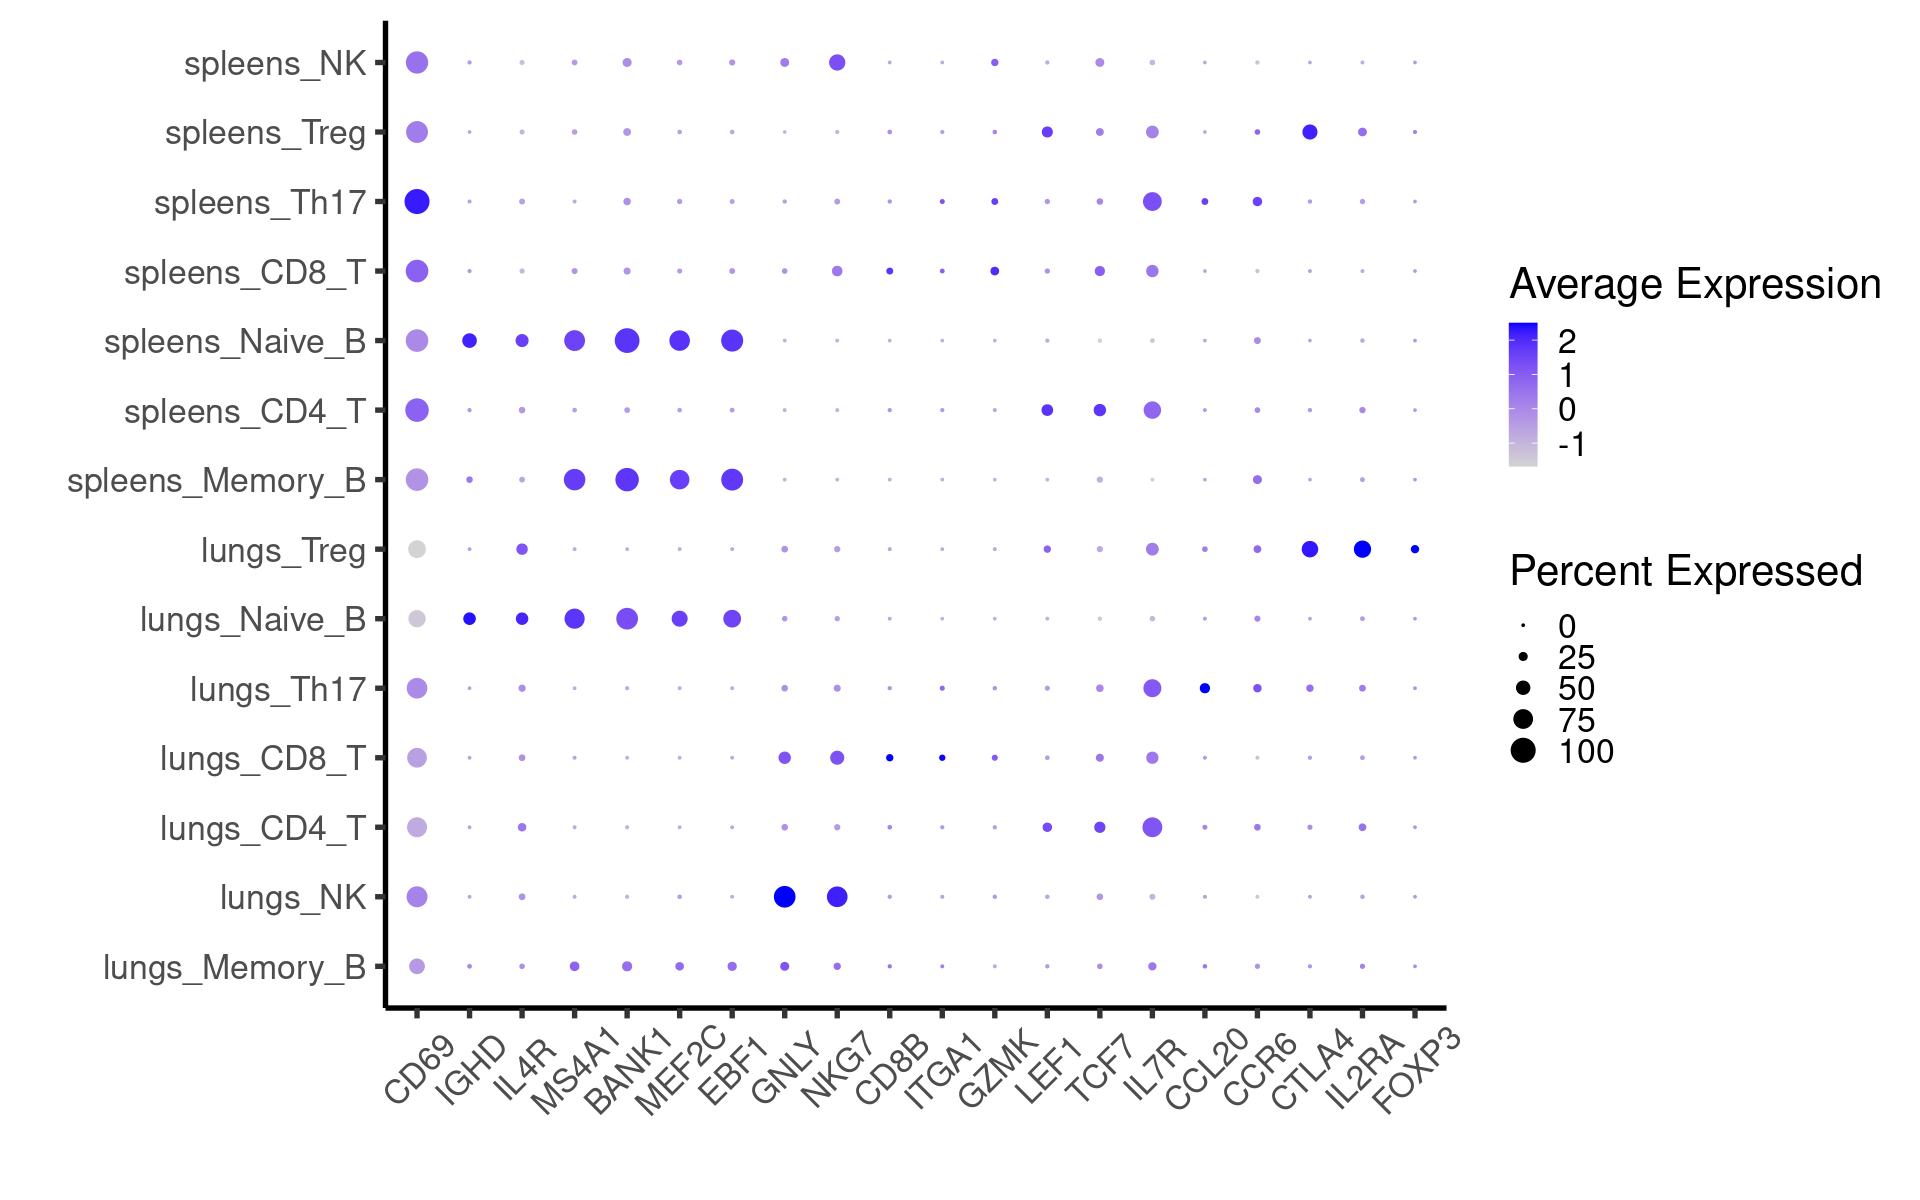

In [8]:
DotPlot(subset(immune.combined, CellType != "Other"), 
        features = markerGenes,
         ) + RotatedAxis() + xlab("") + ylab("") + 
theme_classic(base_size = 25) + 
theme(axis.text.x = element_text(angle = 45, vjust=0.6))

<a id='section4'></a>

## 4 Cross-tissue DE analysis in each cell type 

We performed differential gene expression between tissue with pseudo-bulk samples using DESeq2 (v1.38.3) (Love, Huber, and Anders, 2014). The test was done on the RNA count matrix
aggregated by donor, tissue and cell types using Seurat::AggregateExpression. We also adjusted
for covariates including batch, ethnicity, age, and sex.

In [ ]:
## Prepare aggregated RNA count matrix

sample_cov <- fread("data/sample_covariates.txt")
colnames(sample_cov)[3] <- "library_id"
immune.combined@meta.data <- left_join(immune.combined@meta.data, sample_cov[, 1:8])

immune.combined@meta.data$Batch <- left_join(immune.combined@meta.data, sample_cov) %>% pull(submission_date)
immune.combined@meta.data$Donor <- left_join(immune.combined@meta.data, sample_cov) %>% pull(ROBI)
immune.combined$CellTypeTissue <- paste(immune.combined$CellType, immune.combined$tissue.ident, sep = "_")
Idents(immune.combined) <- "CellTypeTissue"

In [ ]:
## Group cells into pseudobulk by donor, tissue and cell types
pseudo_rna <- AggregateExpression(immune.combined, return.seurat = T, assays = "RNA", 
                                group.by = c("full.ident", "CellType"))

metadata$full.ident <- gsub("_", "-", metadata$full.ident)
pseudo_rna@meta.data$library_id <- 
    left_join(pseudo_rna@meta.data, 
              metadata %>% 
                  mutate(full.ident = gsub("_", "-", full.ident))) %>% 
                  pull(library_id)

# Add rownames to metadata is necessary for seurat function to work.
rownames(pseudo_rna@meta.data) <- pseudo_rna$orig.ident
colnames(pseudo_rna@meta.data)[11] <-"Asthmatic_status"

In [72]:
## Perform cross-tissue DE analysis one cell type at a time with DESeq2

library(DESeq2)
DEG_list <-
    lapply(unique(pseudo_rna@meta.data$CellType), function(i) {
        sub_rna = subset(pseudo_rna, CellType == i)
        dds <- DESeqDataSetFromMatrix(countData = sub_rna@assays$RNA@layers$counts, 
                                  colData = sub_rna@meta.data,
                                  design = ~ factor(submission_date) + Race + Age + Sex + cells)
        dds <- DESeq(dds, betaPrior = FALSE)
        mm <- model.matrix(design(dds), colData(dds))
        qr(mm)$rank
        ncol(mm)
        print(qr(mm)$rank == ncol(mm))
        #print(pairs(~ factor(submission_date) + Race + Asthmatic_status + cells, data = colData(dds)))
        res <- results(dds, contrast = c("cells", "Lung", "Spleen"))
        return(res)
        })

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are s

[1] TRUE


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are s

[1] TRUE


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are s

...

[1] TRUE


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are s

[1] TRUE


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are s

[1] TRUE


In [44]:
## Summarize number of DE genes into a table
DEG_counts <-
    lapply(DEG_list, function(i) {
        data.frame(i) %>% filter(padj <= 0.05) %>% 
            mutate(
                Category = 
                case_when(log2FoldChange > 0.58 ~ "lung-up",
                          log2FoldChange < -0.58 ~ "spleen-up")) %>%
            group_by(Category) %>% dplyr::summarise(n = n())
    })

In [45]:
do.call(rbind, DEG_counts) %>% filter(!is.na(Category)) %>% 
    mutate(CellType = unlist(lapply(names(DEG_list), function(i){rep(i, 2)})))

Category,n
<chr>,<int>
lung-up,193
spleen-up,98
lung-up,91
spleen-up,46
lung-up,116
spleen-up,23
lung-up,107
spleen-up,138
lung-up,115


### Visualize DE results with volcano plots

In [ ]:
## Load cross-tissue DE list
DEG_list <- readRDS("output/u19_multiomics/output/u19_rna/bulk_cross_tissue_DESeq2_full.RDS")
DEG_list <- lapply(names(DEG_list), function(i) {
  data.frame(DEG_list[[i]], cluster = gsub("-", "_", i)) %>%
    filter(!is.na(log2FoldChange))
})

## Make a table of DE genes grouped by effect direction 
DGE_tbl <- do.call(rbind, tests)

gginput <-
    DGE_tbl %>% 
      mutate(avg_log2FC = log2FoldChange) %>%
      filter(cluster != "Other" & padj <= 0.05) %>%
      mutate(group = case_when(avg_log2FC >= 1~ "Lung Up-regulated", 
                                 avg_log2FC <= -1 ~ "Spleen Up-regulated")) 
## Summarize total number of DE genes
totalCounts <- gginput %>% group_by(cluster) %>% dplyr::summarise(n = n())

In [ ]:
## Make a combined volcano plot for DE genes in each cell type
library(ggrepel)
selected <- ct_order[1:5]
gginput <- left_join(totalCounts, gginput, by = "cluster")
gginput$label <- sprintf("%s (%s)", gginput$cluster, gginput$n)
panel_order <-
  unlist(lapply(ct_order[1:5], function(i){levels(factor(gginput$label))[grep(i, levels(factor(gginput$label)))]}))
p1 <-
ggplot(
  gginput %>% filter(cluster %in% selected),
  aes(
    x = avg_log2FC ,
    y = -log10(pvalue),
    color = cluster,
  )
) +
  geom_point(size = 0.5) +
  scale_color_manual(values = c(pal_rna)) + 
  geom_point(
    data =
      gginput %>% 
      filter(padj > 0.05) %>%
      filter(cluster %in% selected),
    aes(x = avg_log2FC, y = -log10(pvalue)),
    color = alpha("grey", 0.7),
    size = 0.5
  ) +
  geom_text_repel(
    data = gginput %>% filter(cluster %in% selected),
    aes(label = ifelse(abs(avg_log2FC) >= 0.58, gene, "")),
    color = "grey30",
    #max.overlaps = 15,
    nudge_x = 0.1, nudge_y = 0.1,
    size = 2) +
  facet_wrap(~ factor(label, levels = panel_order), nrow = 2) +
  theme_pub() + 
  ylab("-log10(p-value)") + #xlim(c(-5, 10)) + 
  theme(legend.position = "none")

### One example, *GNLY*, with large gene expression differences between tissue

In [10]:
# aggregate RNA counts by library_id 
metadata <- data.frame(
    library_id = c(paste("SMO", c(2,3,5,7,8,9), sep = "-"),
                   paste("SMO", c(1,4,10), sep = "-")),
    full.ident = c(paste("lungs", 1:6, sep = "_"),
                   paste("spleens", 1:3, sep = "_")))

immune.combined@meta.data$library_id <- left_join(immune.combined@meta.data, metadata) %>% pull(library_id)
immune.combined@meta.data$CellGroup <- paste(immune.combined$library_id, immune.combined$CellType, sep = "-")
pb <- AggregateExpression(
  object = immune.combined,
  group.by = "CellGroup",
  assays = "RNA",
  slot = "counts"
)

Joining with `by = join_by(full.ident)`
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


In [56]:
p1 <- VlnPlot(immune.combined, features = "GNLY", pt.size = 0, group.by = "CellType", split.by = "tissue.ident") + 
theme_pub(base_size = 15) + theme(legend.position = "none")
p2 <- VlnPlot(immune.combined, features = "GNLY", idents = c("NK_lungs", "NK_spleens"), 
        group.by= "batch_donor", split.by = "tissue.ident") + 
theme_pub(base_size =15) + theme(legend.position = "none", axis.text.x = element_text(angle = 45, vjust = 0.5))

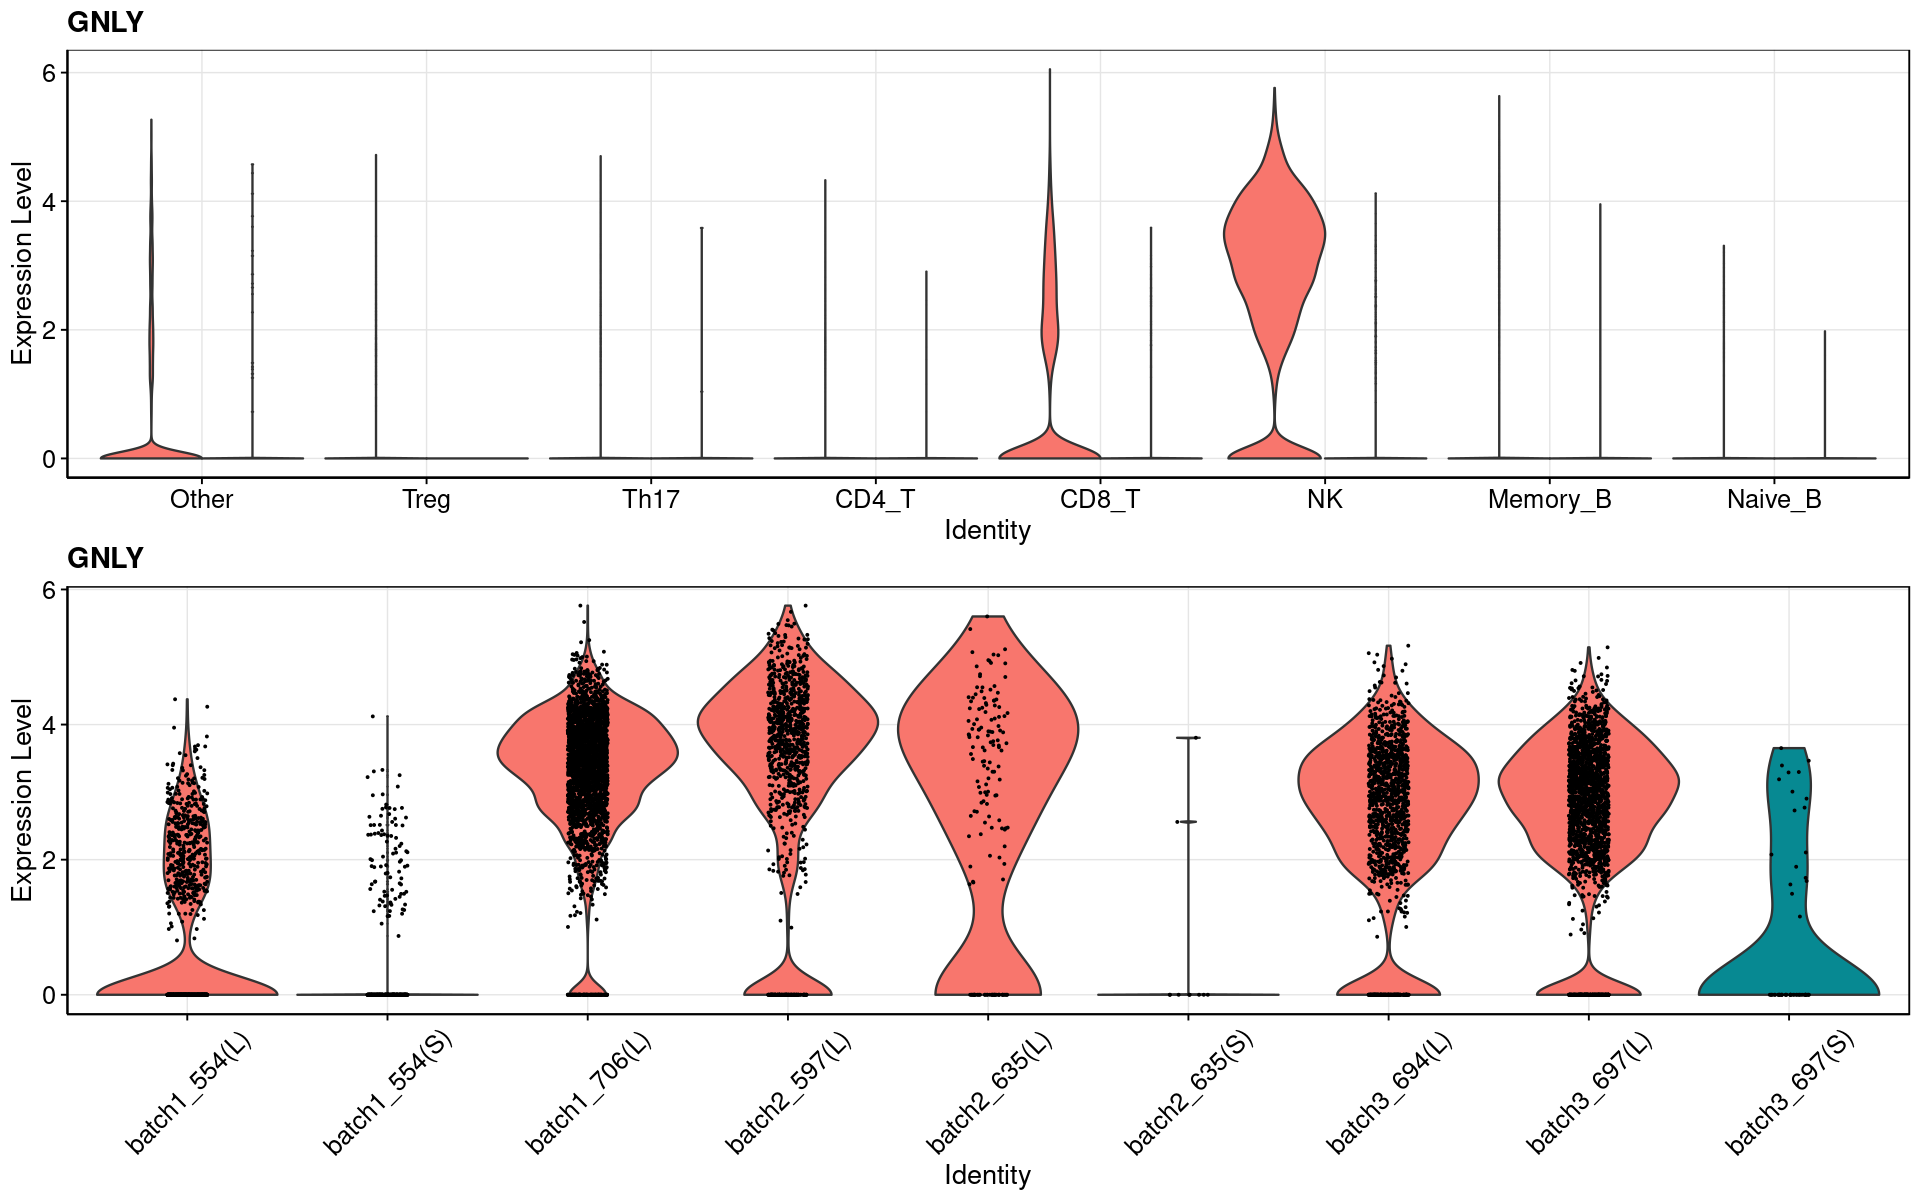

In [57]:
p1/p2

<a id='section5'></a>

## Examine the functions of lung or spleen DE genes 

We performed GO enrichment test for DE genes one cell type at at time separately for each tissue.

In [ ]:
## Prepare inputs for GO enrichment
bkgGenes <- unique(tests$Other$gene)
lung_up <- gginput[gginput$group == "Lung Up-regulated", ]
genesets <- lapply(split(lung_up, lung_up$cluster), function(i) {i$gene})
spleen_up <- gginput[gginput$group == "Spleen Up-regulated", ]
genesets <- lapply(split(spleen_up, spleen_up$cluster), function(i) {i$gene})

In [ ]:
## Bash 
Rscript --vanilla code/run_GO_enrichment.R --geneset lung_up.RDS --bkg genesets.RDS --out lung_upreg
Rscript --vanilla code/run_GO_enrichment.R --geneset spleen_up.RDS --bkg genesets.RDS --out spleen_upreg

In [ ]:
## Visulize GO enrichment outputs
go_list <- readRDS("lung_upreg_GO_enrichment.RDS")
feature = "Biological"
go_tbl <-
  do.call(rbind, go_list) %>%
    filter(k %in% ct_order[1:5])
write.table(go_tbl %>% filter(FDR <= 0.05 & grepl("Biological", database)) %>% dplyr::select(-database), "tables/Enriched_GO_BP_lungUp.txt", quote = F, sep = "\t")
toshow <- 
    unique(
      go_tbl %>% 
        filter(FDR <= 0.05 & grepl(feature, database)) %>%
            group_by(k) %>%
            slice_max(n = 7, order_by = enrichmentRatio) %>%
            pull(description))
p2 <-
ggplot(
    go_tbl %>% 
      filter(grepl(feature, database) & description %in% toshow & 
               FDR <= 0.05) %>%
      mutate(FDR = ifelse(FDR == 0, 10^(-10), FDR),
             Enrichment = enrichmentRatio),
    aes(y = description,
        x = factor(k, levels = ct_order[1:5]),
        size = Enrichment,
        color = -log10(FDR))) + 
    geom_point() + xlab("") + ylab("") + 
     # scale_fill_gradient(
     #   limits = c(0, 4),
     #   oob = squish) +
    theme_pub() + #ggtitle("GO BP enrichment for lung up-regulated genes") 
    theme(axis.text.x = element_text(angle = 45, vjust = 0.5),
          axis.text.y = element_text(),
          legend.position = "bottom")
p2

In [ ]:
go_list <- readRDS("spleen_upreg_GO_enrichment.RDS")
feature = "Biological"
go_tbl <-
  do.call(rbind, go_list) %>%
    filter(k %in% ct_order[1:5])
write.table(go_tbl %>% filter(FDR <= 0.1 & grepl("Biological", database)) %>% dplyr::select(-database), "tables/Enriched_GO_BP_spleenUp.txt", quote = F, sep = "\t")

toshow <- 
    go_tbl %>% 
      filter(FDR <= 0.1 & grepl(feature, database)) %>%
          group_by(k) %>%
          #slice_max(n = 8, order_by = enrichmentRatio) %>%
          pull(description)

ggplot(
    go_tbl %>% 
      filter(grepl(feature, database) & description %in% toshow),
    aes(y = description,
        x = factor(k, levels = ct_order[1:5]),
        size = enrichmentRatio,
        color = -log10(FDR_adj))) + 
    geom_point() + xlab("") + ylab("") + 
     # scale_fill_gradient(
     #   limits = c(0, 4),
     #   oob = squish) +
    theme_pub() + ggtitle("GO BP enrichment for spleen up-regulated genes") 
    #theme(axis.text.x = element_text(angle = 45, vjust = 0.5))

In [ ]:
new_list <- lapply(go_list, function(i){
        z<-mutate(i, richFactor = Count / as.numeric(sub("/\\d+", "", BgRatio)))
        return(z)
    })

go_plots<-list()
for(c in names(new_list)){
    go_plots[[c]]<-ggplot(new_list[[c]], showCategory = 20, 
                        aes(richFactor, fct_reorder(Description, richFactor))) + 
                            geom_segment(aes(xend=0, yend = Description)) +
                            geom_point(aes(color=qvalue, size = Count)) +
                            scale_color_viridis_c(guide=guide_colorbar(reverse=TRUE)) +
                            scale_size_continuous(range=c(2, 10)) +
                            theme_minimal() + theme(axis.text.y=element_text(size=12)) + 
                            xlab("rich factor") +
                            ylab(NULL) + 
                            ggtitle(c)
    }
saveRDS(new_list, "~/cluster/projects/u19_multiomics/analyses/go_BP_results.rds")

In [ ]:
options(repr.plot.width=18, repr.plot.height=18)
marrangeGrob(go_plots[c(3,4,5,8)], nrow=2, ncol=2)

In [ ]:
options(repr.plot.width=18, repr.plot.height=16)
marrangeGrob(go_plots[c(2,6,10)], nrow=2, ncol=2)

In [ ]:
marrangeGrob(go_plots[c(1,7,9,11)], nrow=2, ncol=2)

In [ ]:
library(Signac)

In [ ]:
1_3

In [ ]:
head(immune.combined@meta.data)

In [ ]:
saveRDS(immune.combined, paste0(work.dir, "/analyses/lungs_spleens_processed.rds"))

In [ ]:
immune.atac<-RunUMAP(immune.combined, reduction = "lsi", dims = 2:30, reduction.name = "umap.atac", reduction.key = "atacUMAP_")

In [ ]:
immune.combined@assays$RNA@counts